# MiBiReMo column model validation against mibitrans

The laboratory column of the example column_reactive_transport_test, flushed without interruption, is compared with the exact analytical solution of
the [mibitrans](https://github.com/MiBiPreT/mibitrans) package (`pip install mibitrans`) for a conservative tracer (Tr) and
a solute degraded with first-order kinetics (Dk). The column is initially free of both, and the influent has a constant
concentration C_in from t = 0.

mibitrans computes the plume from a constant-concentration source in uniform flow (Wexler, 1992). With a negligible
transverse dispersivity and a wide and deep source, its concentration on the centreline is the one-dimensional solution
of the column.

In [1]:
import math
from importlib.resources import files
from pathlib import Path
import matplotlib.pyplot as plt
import mibitrans as mbt
import numpy as np
from mibitrans.analysis.differences import rmse
import mibiremo as mb

MINUTE, HOUR, DAY = 60.0, 3600.0, 86400.0
OUTPUT = (Path(__file__).parent if "__file__" in globals() else Path()) / "output"  # next to this script or notebook
OUTPUT.mkdir(exist_ok=True)

## PHREEQC database

Kinetic rates must be defined in the RATES block of the database. Here `phreeqc.dat` is extended with two elements, Tr
and Dk (gram formula weight 1), and a rate "Dk" for first-order decay, r = λ C, with λ = `PARM(1)` [s⁻¹].

In [2]:
definitions = """
SOLUTION_MASTER_SPECIES
Tr       Tr       0     Tr     1.0
Dk       Dk       0     Dk     1.0
SOLUTION_SPECIES
Tr = Tr
    log_k 0
Dk = Dk
    log_k 0
RATES
Dk
-start
10 SAVE PARM(1) * TOT("Dk") * TIME
-end
"""
text = (files("mibiremo") / "database" / "phreeqc.dat").read_text(encoding="latin-1")
database = OUTPUT / "column.dat"
database.write_text(text.replace("\nEND\n", definitions + "END\n", 1), encoding="latin-1")

48571

## Column model

The column of column_reactive_transport_test with a constant flow rate of 1 mL/min, simulated for 8 h. The 60 cells
of 5 mm and the time step of 3 min give a Courant number v Δt / Δx of 0.8.

In [3]:
length, diameter, porosity = 0.3, 0.05, 0.38  # L [m], d [m], n [-]
dispersivity, diffusion = 0.005, 1e-9  # alpha_L [m], D* [m2/s]
flow_rate = 1e-6 / MINUTE  # 1 mL/min in m3/s
half_life = 2 * HOUR
n_cells, time_step, simulation_time = 60, 3 * MINUTE, 8 * HOUR
model = mb.ColumnModel(
    workspace=OUTPUT / "validation_column_vs_mibitrans",
    length=length,
    diameter=diameter,
    porosity=porosity,
    flow_rate=flow_rate,
    longitudinal_dispersivity=dispersivity,
    diffusion_coefficient=diffusion,
    n_cells=n_cells,
    simulation_time=simulation_time,
    time_step=time_step,
    database=database,
    solutions={1: {}, 2: {"Tr": 1e-3, "Dk": 1e-3}},  # mol/kgw
    initial_solution=1,
    influent_solution=2,
    kinetics={1: {"Dk": {"m0": 1.0, "parms": [math.log(2) / half_life], "formula": "Dk -1"}}},
    initial_kinetics=1,
)
model.run()
velocity = flow_rate / (porosity * math.pi * diameter**2 / 4)  # v = Q / (n A)
print(
    f"Pore-water velocity {velocity * DAY:.2f} m/d, travel time through the column {length / velocity / HOUR:.1f} h, "
    f"Courant number {velocity * time_step / (length / n_cells):.2f}"
)

Pore-water velocity 1.93 m/d, travel time through the column 3.7 h, Courant number 0.80


## Analytical solution

mibitrans works in m and days: the velocity, the decay rate constant λ = ln 2 / t½, and the diffusion coefficient are
converted from seconds to days. A transverse dispersivity of 1e-6 m and a source 0.1 m wide and 1 m deep give the
one-dimensional limit on the centreline (y = 0). mibitrans computes C / C_in every 15 min at x = 0, Δx, ..., L; the
points with x > 0 are those of the column model (`model.x`).

In [4]:
analytical = {}
for component, decay_rate in [("Tr", 0.0), ("Dk", math.log(2) / half_life)]:
    solution = mbt.Mibitrans(
        mbt.HydrologicalParameters(
            velocity=velocity * DAY, porosity=porosity, alpha_x=dispersivity, alpha_y=1e-6, diffusion=diffusion * DAY
        ),
        mbt.AttenuationParameters(decay_rate=decay_rate * DAY),
        mbt.SourceParameters(np.array([0.05]), np.array([1.0]), depth=1.0),
        mbt.ModelParameters(
            model_length=length,
            model_width=0.1,
            model_time=simulation_time / DAY,
            dx=length / n_cells,
            dy=0.05,
            dt=15 * MINUTE / DAY,
        ),
    )
    analytical[component] = solution.run().relative_cxyt[:, np.argmin(abs(solution.y)), 1:]  # centreline, x > 0

## Comparison

The concentrations of the column model, in mol/m³, are divided by C_in = 1 mmol/kgw × 997 kg/m³ (density of water at
25 °C), at the times of mibitrans. The largest differences, about 3 % of C_in, are at the front in the first 15 min
and at the outlet, where the column has a zero concentration gradient while the analytical solution is for a
semi-infinite domain.

In [5]:
influent = 1e-3 * 997.0  # C_in [mol m-3]
numerical = {}
for component in analytical:
    numerical[component] = np.array([model.concentration(component, t * DAY) for t in solution.t]) / influent
    error = rmse(analytical[component], numerical[component], axis=(0, 1))
    print(f"{component}: root-mean-square difference of C/C_in = {error:.3f}")

Tr: root-mean-square difference of C/C_in = 0.003
Dk: root-mean-square difference of C/C_in = 0.008


## Concentration profiles

Lines: mibitrans; points: column model. The front of the tracer moves at the pore-water velocity and spreads by
dispersion. Dk decays along the column and reaches a steady state (6 h), where the decay balances the transport.

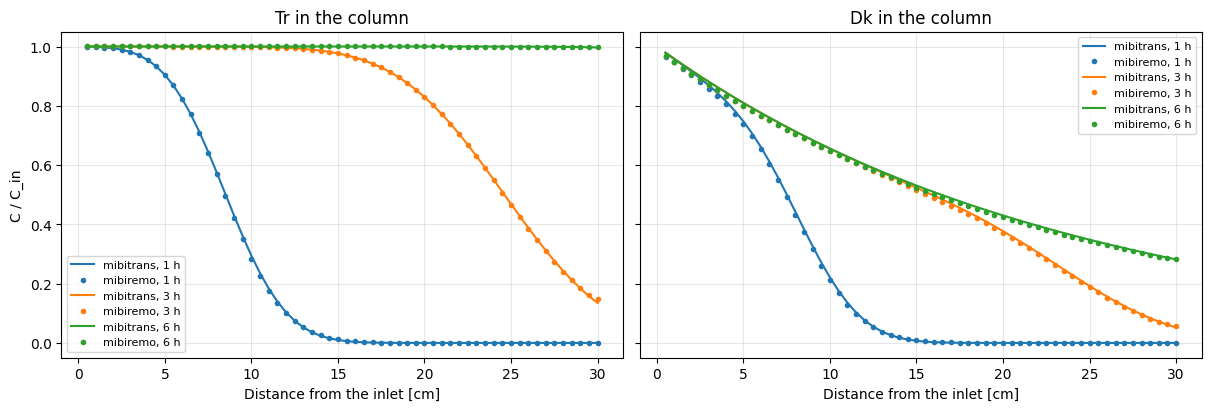

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained", sharey=True)
for ax, component in zip(axes, ["Tr", "Dk"]):
    for hours, color in [(1, "tab:blue"), (3, "tab:orange"), (6, "tab:green")]:
        k = np.argmin(abs(solution.t - hours * HOUR / DAY))
        ax.plot(model.x * 100, analytical[component][k], color=color, label=f"mibitrans, {hours} h")
        ax.plot(model.x * 100, numerical[component][k], "o", color=color, ms=3, label=f"mibiremo, {hours} h")
    ax.set(xlabel="Distance from the inlet [cm]", title=f"{component} in the column")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
axes[0].set_ylabel("C / C_in")
plt.show()

## Breakthrough curves

Effluent concentration (x = L) against the pore volumes flushed, V / V_p = Q t / V_p. The tracer reaches C/C_in = 0.5
after about one pore volume; Dk reaches a steady state at C/C_in = 0.28.

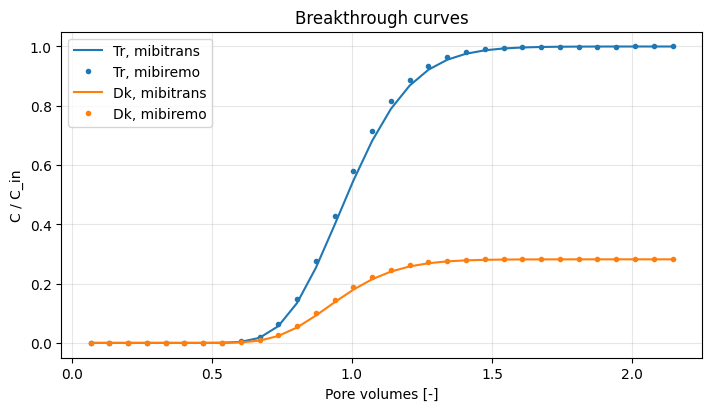

In [7]:
pore_volumes = flow_rate * solution.t * DAY / model.pore_volume
fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
for component, color in [("Tr", "tab:blue"), ("Dk", "tab:orange")]:
    ax.plot(pore_volumes, analytical[component][:, -1], color=color, label=f"{component}, mibitrans")
    ax.plot(pore_volumes, numerical[component][:, -1], "o", color=color, ms=3, label=f"{component}, mibiremo")
ax.set(xlabel="Pore volumes [-]", ylabel="C / C_in", title="Breakthrough curves")
ax.grid(alpha=0.3)
ax.legend()
plt.show()